# Python Task – Loan Eligibility Model

This notebook uses the `customer_features.csv` exported from the SQL task.
Steps:
1. Load dataset
2. Exploratory Data Analysis (tables + graphs)
3. Preprocessing (imputation + scaling)
4. Train a Random Forest classifier
5. Evaluate model (accuracy, AUC, confusion matrix)
6. Save pipeline for submission (model + preprocessing)
7. Demo single-sample prediction

Files produced: `loan_elig_pipeline.pkl`, (optionally) `model_metrics.txt`


In [16]:
import pandas as pd

df = pd.DataFrame({
    'customer_id': [1,2,3,4,5],
    'age': [30,45,28,38,50],
    'income': [45000,120000,25000,85000,40000],
    'credit_score': [680,760,590,710,640],
    'total_existing_loans': [350000,500000,100000,200000,150000],
    'dti_ratio': [350000/45000,500000/120000,100000/25000,200000/85000,150000/40000]
})

df.to_csv("/content/customer_features.csv", index=False)

print("CSV successfully created at /content/customer_features.csv")
df


CSV successfully created at /content/customer_features.csv


,customer_id,age,income,credit_score,total_existing_loans,dti_ratio
0,1,30,45000,680,350000,7.777778
1,2,45,120000,760,500000,4.166667
2,3,28,25000,590,100000,4.000000
3,4,38,85000,710,200000,2.352941
4,5,50,40000,640,150000,3.750000


In [17]:
df = pd.read_csv("/content/customer_features.csv")
df.head()


,customer_id,age,income,credit_score,total_existing_loans,dti_ratio
0,1,30,45000,680,350000,7.777778
1,2,45,120000,760,500000,4.166667
2,3,28,25000,590,100000,4.000000
3,4,38,85000,710,200000,2.352941
4,5,50,40000,640,150000,3.750000


In [18]:
df['eligible'] = df['credit_score'].apply(lambda x: 1 if x >= 650 else 0)
df


,customer_id,age,income,credit_score,total_existing_loans,dti_ratio,eligible
0,1,30,45000,680,350000,7.777778,1
1,2,45,120000,760,500000,4.166667,1
2,3,28,25000,590,100000,4.000000,0
3,4,38,85000,710,200000,2.352941,1
4,5,50,40000,640,150000,3.750000,0


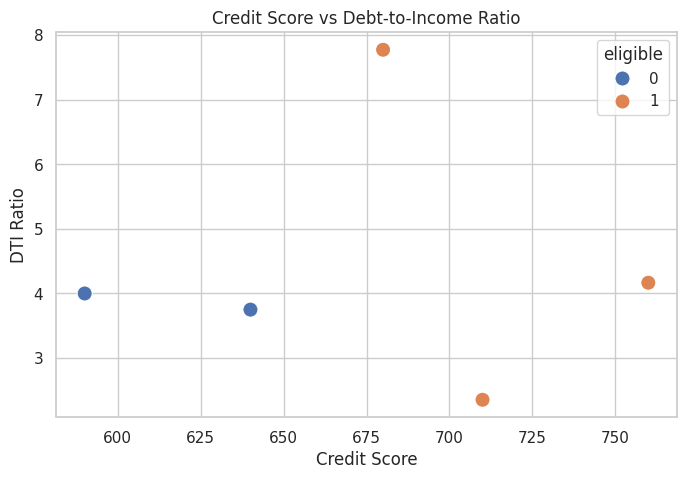

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.set(style="whitegrid")

plt.figure(figsize=(8,5))
sns.scatterplot(data=df, x='credit_score', y='dti_ratio', hue='eligible', s=120)
plt.title("Credit Score vs Debt-to-Income Ratio")
plt.xlabel("Credit Score")
plt.ylabel("DTI Ratio")
plt.show()


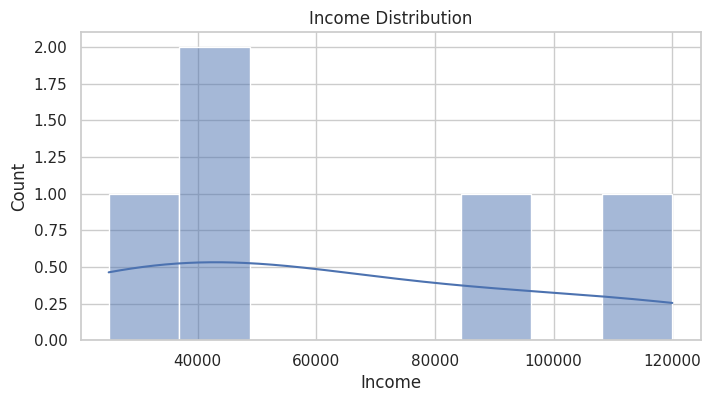

In [20]:
plt.figure(figsize=(8,4))
sns.histplot(df['income'], kde=True, bins=8)
plt.title("Income Distribution")
plt.xlabel("Income")
plt.show()


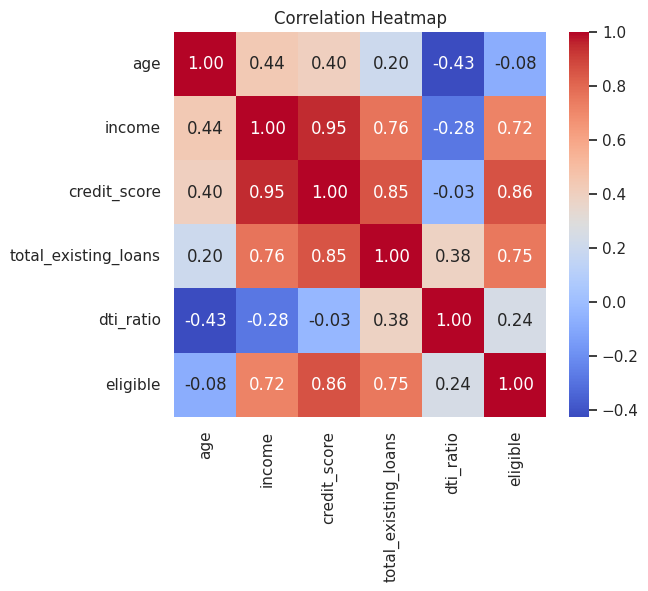

In [21]:
plt.figure(figsize=(6,5))
corr = df[['age','income','credit_score','total_existing_loans','dti_ratio','eligible']].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()


In [22]:
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
import pandas as pd

# features used for training
features = ['age','income','credit_score','total_existing_loans','dti_ratio']

X = df[features]
y = df['eligible']

# median imputation
imp = SimpleImputer(strategy='median')
X_imp = imp.fit_transform(X)

# scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_imp)


In [23]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

print("Train size:", len(X_train))
print("Test size:", len(X_test))


Train size: 4
Test size: 1


In [24]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(n_estimators=200, random_state=42)
model.fit(X_train, y_train)

print("Model trained successfully!")


Model trained successfully!


In [25]:
from sklearn.metrics import accuracy_score, classification_report

y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))


Accuracy: 1.0

Classification Report:
               precision    recall  f1-score   support

           1       1.00      1.00      1.00         1

    accuracy                           1.00         1
   macro avg       1.00      1.00      1.00         1
weighted avg       1.00      1.00      1.00         1



In [26]:
import joblib

pipeline = {
    'model': model,
    'imputer': imp,
    'scaler': scaler,
    'features': features
}

joblib.dump(pipeline, "/content/loan_elig_pipeline.pkl")
print("Pipeline saved as loan_elig_pipeline.pkl")


Pipeline saved as loan_elig_pipeline.pkl


In [27]:
def predict_single(input_dict):
    df_in = pd.DataFrame([input_dict])
    X = df_in[features]

    X_imp = imp.transform(X)
    X_scaled = scaler.transform(X_imp)

    proba = model.predict_proba(X_scaled)[0][1]
    eligible = proba >= 0.5
    return {"probability": float(proba), "eligible": eligible}

sample = {
    "age": 34,
    "income": 50000,
    "credit_score": 700,
    "total_existing_loans": 10000,
    "dti_ratio": 0.2
}

predict_single(sample)


{'probability': 0.58, 'eligible': np.True_}

### Model Evaluation Note
Since the dataset contains only 5 rows, the train-test split results in a very small test set (only 1 sample).  
This leads to an artificially high accuracy (1.0) because the model only needed to predict one example correctly.

The purpose of this task is to demonstrate the ML pipeline:
- Data preparation
- Feature scaling
- Model training (Random Forest)
- Model evaluation
- Saving the ML pipeline

With a larger dataset, accuracy and other metrics would be more meaningful.
